# Fase B – EDA, PCA y k-Means

Este notebook genera todos los gráficos de la Fase B:

1. Distribuciones después de imputación por mediana  
2. Scatter Plot: `Glucose` vs `BMI` coloreado por `Outcome`  
3. Mapa de calor de correlaciones  
4. PCA Scree Plot  
5. PCA Biplot: `PC1` vs `PC2`  
6. Selección de `k` con Silhouette Score  
7. Silhouette Plot detallado para el `k` seleccionado  
8. Clústeres k-Means visualizados en plano PCA  
9. Tabla de perfil de clústeres  

Metodología:
- EDA: datos imputados por mediana en unidades originales.
- PCA y k-Means: variables clínicas normalizadas.
- `Outcome` se conserva para colorear e interpretar, pero no entra como variable de entrada en PCA ni k-Means.

In [ ]:
# Si estás en Google Colab, ejecuta esta celda para subir el CSV.
# Si ya tienes el archivo en el entorno, puedes saltarla.
try:
    from google.colab import files
    uploaded = files.upload()
except Exception:
    print("No estás en Google Colab o no se requiere carga manual.")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

plt.rcParams["figure.dpi"] = 120

## 1. Cargar dataset

In [2]:
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

# Cambia este nombre si tu archivo se llama diferente.
file_path = "/content/pima_diabetes_data.csv"

df = pd.read_csv(file_path)

# Si el archivo no trae encabezados correctos, recargar sin encabezado.
if "Glucose" not in df.columns:
    df = pd.read_csv(file_path, header=None)
    df.columns = columns

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Limpieza: ceros clínicamente inválidos e imputación por mediana

In [3]:
df_clean = df.copy()

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

medians = df_clean[invalid_zero_cols].median()
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].fillna(medians)

print("Medianas usadas para imputación:")
display(medians.to_frame("Mediana"))

df_clean.head()

Medianas usadas para imputación:


,Mediana
Glucose,117.0
BloodPressure,72.0
SkinThickness,29.0
Insulin,125.0
BMI,32.3


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 3. Estadísticas descriptivas

In [4]:
features = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

stats = df_clean[features].agg(["mean", "median", "std"]).T
stats.columns = ["Media", "Mediana", "Desviación estándar"]
stats.round(2)

,Media,Mediana,Desviación estándar
Pregnancies,3.85,3.00,3.37
Glucose,121.66,117.00,30.44
BloodPressure,72.39,72.00,12.10
SkinThickness,29.11,29.00,8.79
Insulin,140.67,125.00,86.38
BMI,32.46,32.30,6.88
DiabetesPedigreeFunction,0.47,0.37,0.33
Age,33.24,29.00,11.76


## 4. Distribuciones principales después de imputación por mediana

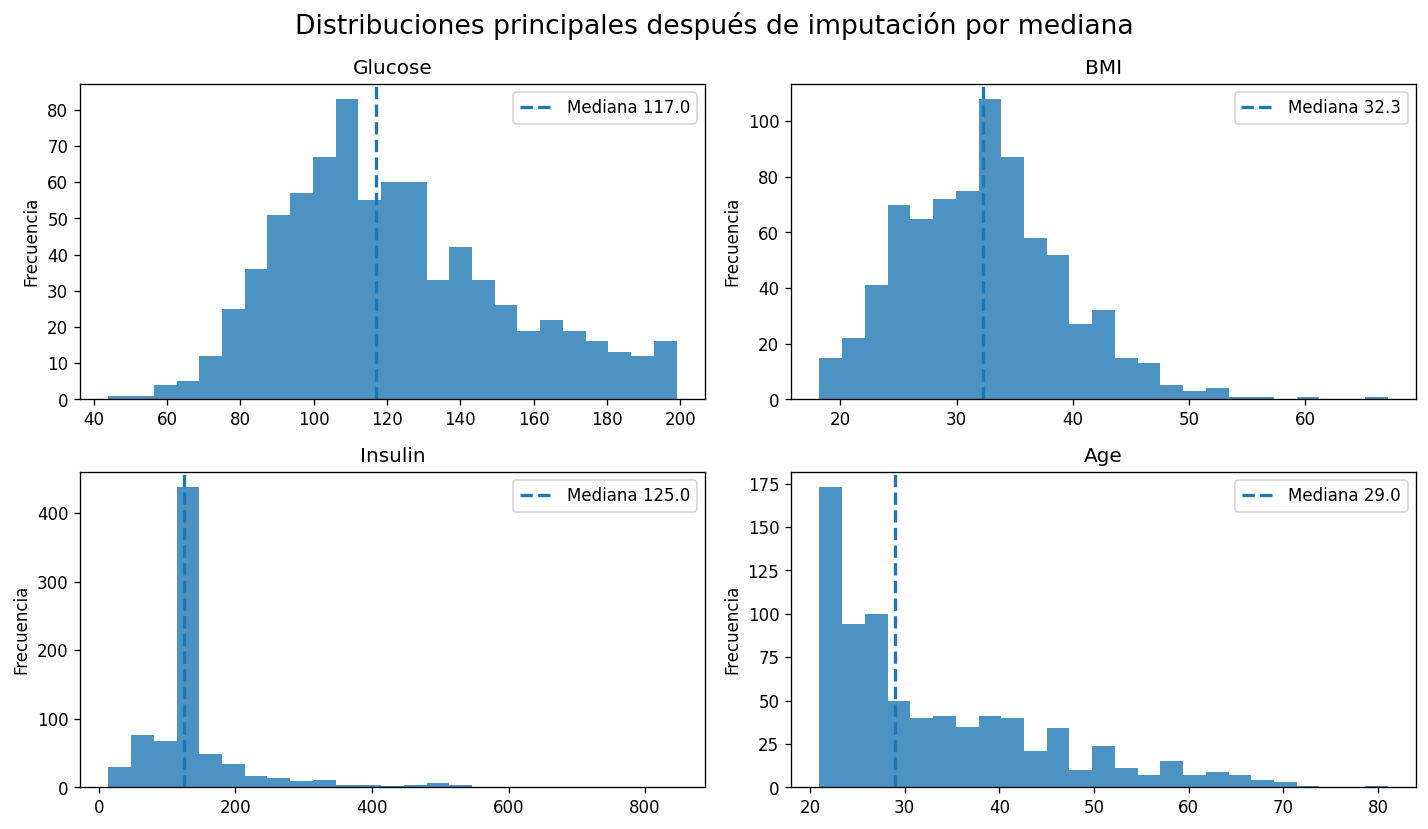

In [7]:
distribution_vars = ["Glucose", "BMI", "Insulin", "Age"]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for ax, var in zip(axes, distribution_vars):
    ax.hist(df_clean[var], bins=25, alpha=0.8)
    median_value = df_clean[var].median()
    ax.axvline(median_value, linestyle="--", linewidth=2, label=f"Mediana {median_value:.1f}")
    ax.set_title(var)
    ax.set_ylabel("Frecuencia")
    ax.legend()

fig.suptitle("Distribuciones principales después de imputación por mediana", fontsize=16)
fig.tight_layout()
plt.show()

## 5. Scatter Plot: Glucose vs BMI coloreado por Outcome

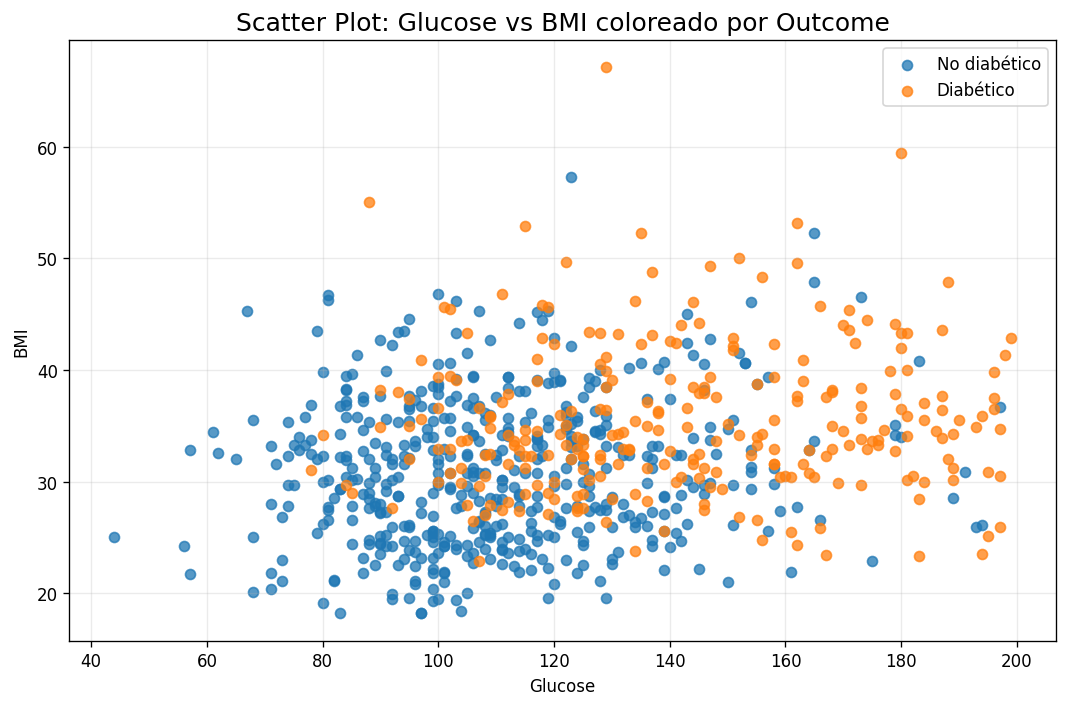

In [8]:
labels = {0: "No diabético", 1: "Diabético"}

plt.figure(figsize=(9, 6))

for outcome_value, label in labels.items():
    subset = df_clean[df_clean["Outcome"] == outcome_value]
    plt.scatter(subset["Glucose"], subset["BMI"], alpha=0.75, label=label)

plt.title("Scatter Plot: Glucose vs BMI coloreado por Outcome", fontsize=15)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Mapa de calor de correlaciones

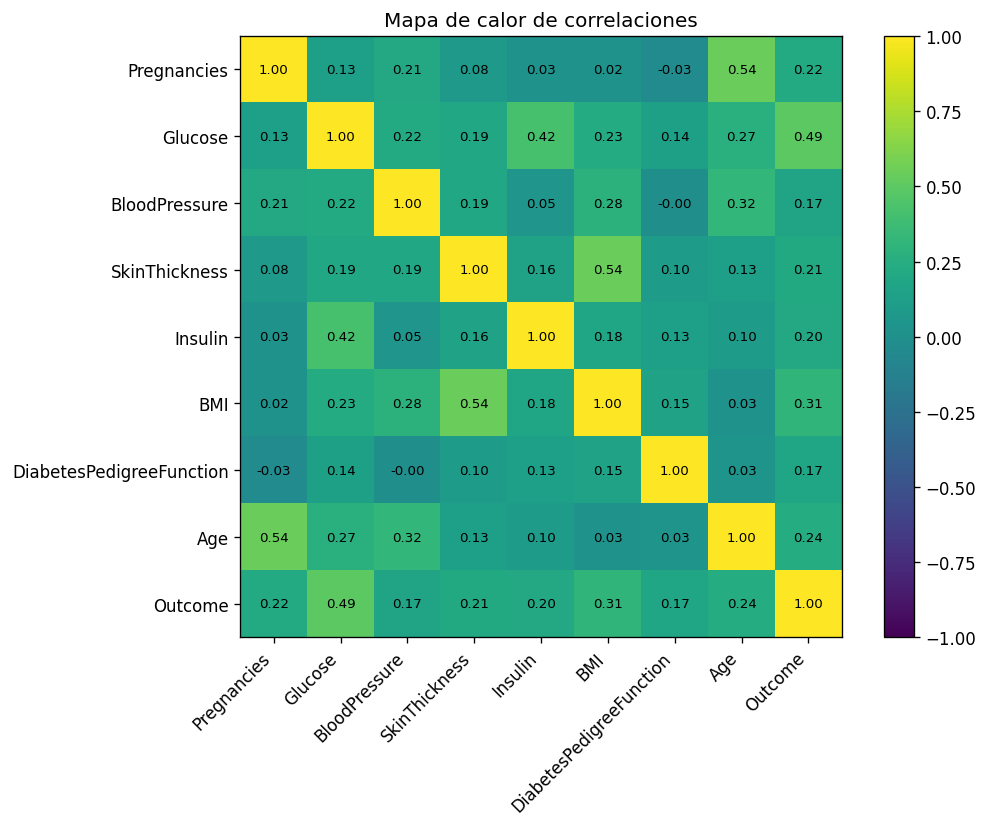

,Outcome
Glucose,0.493
BMI,0.312
Age,0.238
Pregnancies,0.222
SkinThickness,0.215
Insulin,0.204
DiabetesPedigreeFunction,0.174
BloodPressure,0.166


In [9]:
corr_cols = features + ["Outcome"]
corr = df_clean[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Mapa de calor de correlaciones")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

corr["Outcome"].drop("Outcome").sort_values(ascending=False).round(3)

## 7. Preparación para PCA y k-Means

In [10]:
X_original = df_clean[features].copy()
y = df_clean["Outcome"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original)

pd.DataFrame(X_scaled, columns=features).head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


## 8. PCA Scree Plot

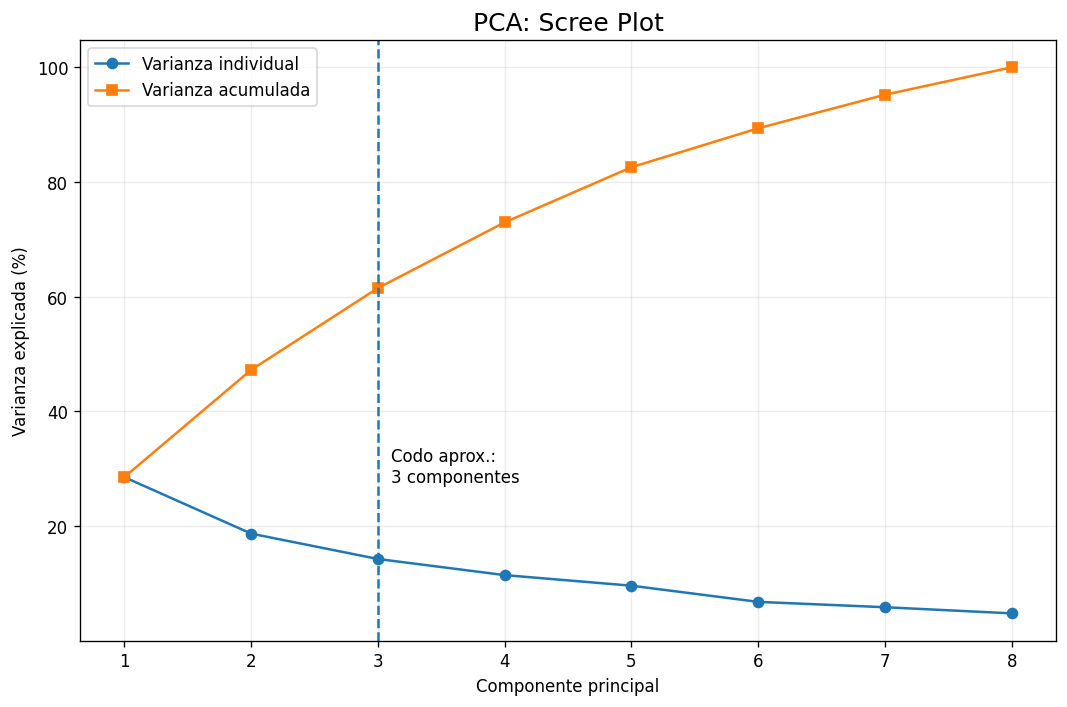

,Componente,Varianza individual (%),Varianza acumulada (%)
0,PC1,28.54,28.54
1,PC2,18.69,47.23
2,PC3,14.27,61.50
3,PC4,11.46,72.96
4,PC5,9.61,82.57
5,PC6,6.79,89.36
6,PC7,5.86,95.21
7,PC8,4.79,100.00


In [11]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

components = np.arange(1, len(explained) + 1)
selected_components = 3

plt.figure(figsize=(9, 6))
plt.plot(components, explained, marker="o", label="Varianza individual")
plt.plot(components, cumulative, marker="s", label="Varianza acumulada")
plt.axvline(selected_components, linestyle="--", linewidth=1.5)

plt.text(
    selected_components + 0.1,
    cumulative[selected_components - 1] * 0.45,
    f"Codo aprox.:\n{selected_components} componentes"
)

plt.title("PCA: Scree Plot", fontsize=15)
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada (%)")
plt.xticks(components)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

pca_variance_table = pd.DataFrame({
    "Componente": [f"PC{i}" for i in components],
    "Varianza individual (%)": explained,
    "Varianza acumulada (%)": cumulative
})

pca_variance_table.round(2)

## 9. PCA Biplot: PC1 vs PC2

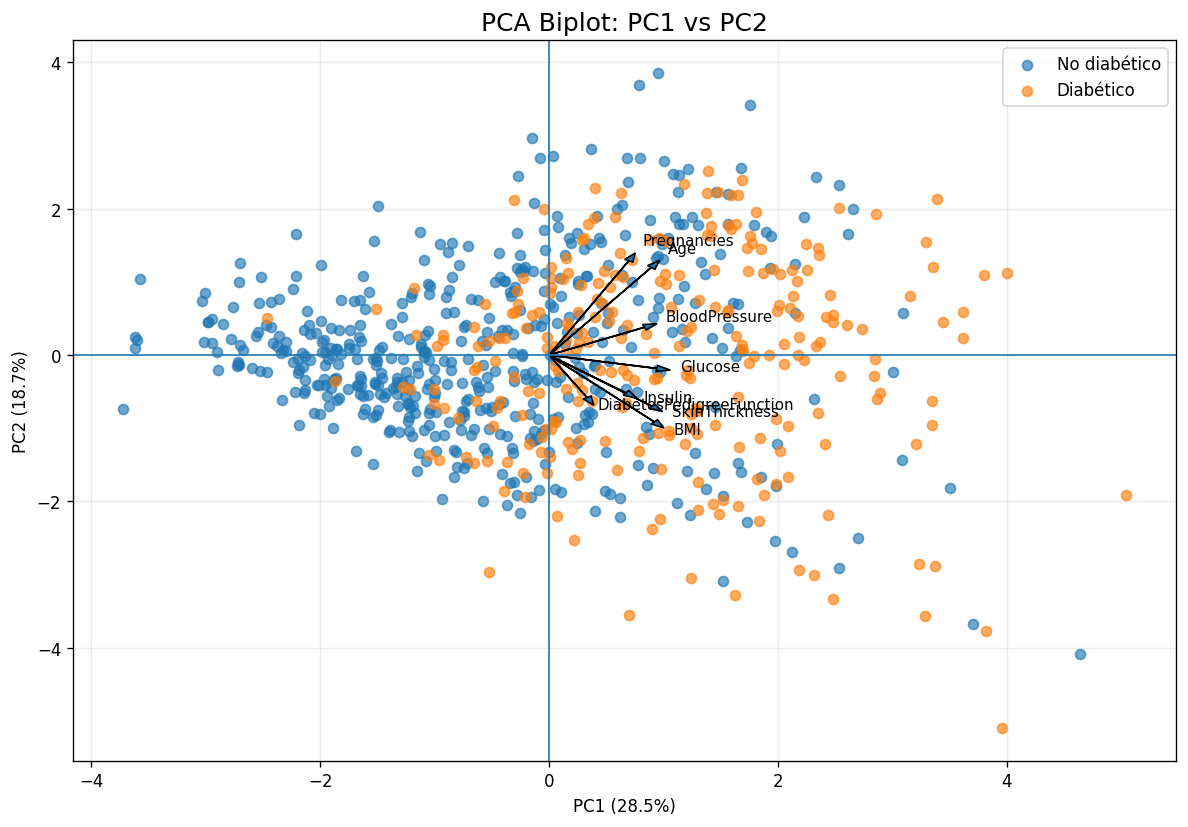

In [12]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

pc1_var = pca_2.explained_variance_ratio_[0] * 100
pc2_var = pca_2.explained_variance_ratio_[1] * 100

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Outcome"] = y.values

plt.figure(figsize=(10, 7))

for outcome_value, label in labels.items():
    subset = pca_df[pca_df["Outcome"] == outcome_value]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.65, label=label)

loadings = pca_2.components_.T
arrow_scale = 2.5

for i, feature in enumerate(features):
    x_loading = loadings[i, 0] * arrow_scale
    y_loading = loadings[i, 1] * arrow_scale
    plt.arrow(0, 0, x_loading, y_loading, head_width=0.08, length_includes_head=True)
    plt.text(x_loading * 1.08, y_loading * 1.08, feature, fontsize=9)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("PCA Biplot: PC1 vs PC2", fontsize=15)
plt.xlabel(f"PC1 ({pc1_var:.1f}%)")
plt.ylabel(f"PC2 ({pc2_var:.1f}%)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Selección de k con Silhouette Score

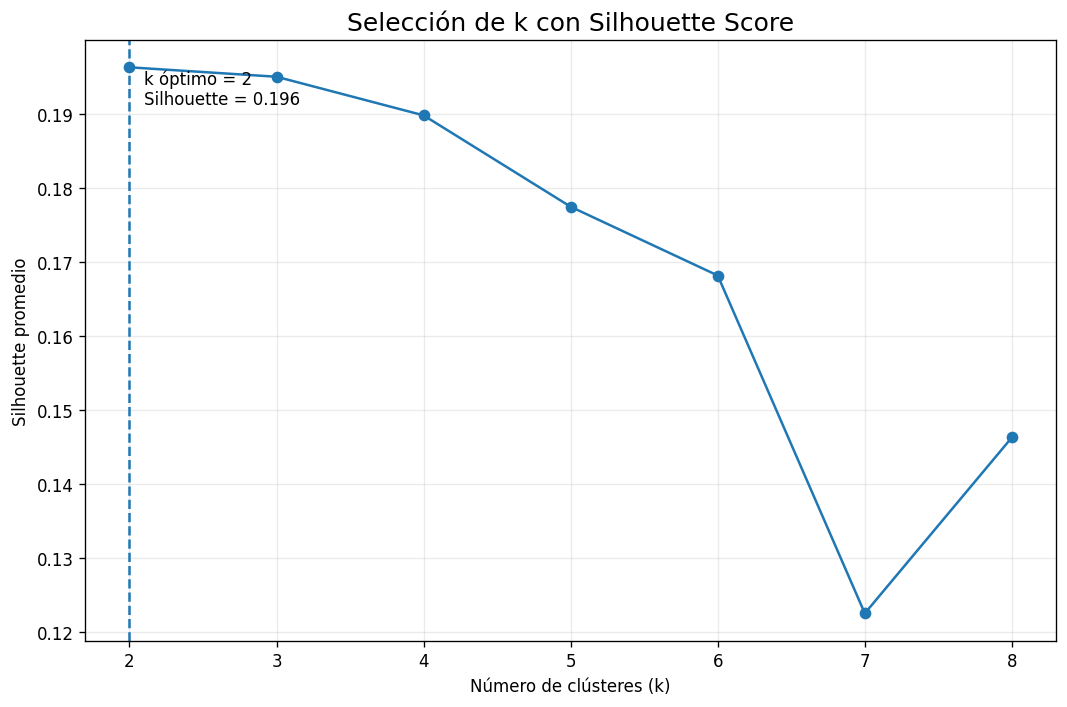

,k,Silhouette Score
0,2,0.196
1,3,0.195
2,4,0.190
3,5,0.177
4,6,0.168
5,7,0.123
6,8,0.146


In [13]:
k_values = list(range(2, 9))
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

best_index = int(np.argmax(silhouette_scores))
best_k = k_values[best_index]
best_score = silhouette_scores[best_index]

plt.figure(figsize=(9, 6))
plt.plot(k_values, silhouette_scores, marker="o")
plt.axvline(best_k, linestyle="--", linewidth=1.5)

plt.text(best_k + 0.1, best_score - 0.005, f"k óptimo = {best_k}\nSilhouette = {best_score:.3f}")

plt.title("Selección de k con Silhouette Score", fontsize=15)
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Silhouette promedio")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

silhouette_table = pd.DataFrame({
    "k": k_values,
    "Silhouette Score": silhouette_scores
})

silhouette_table.round(3)

## 11. Aplicar k-Means con el mejor k

In [14]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_result = df_clean.copy()
df_result["Cluster_original"] = clusters
df_result["PC1"] = X_pca[:, 0]
df_result["PC2"] = X_pca[:, 1]

df_result.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster_original,PC1,PC2
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,0,1.449481,0.659769
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,1,-1.498835,-0.076049
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,0,0.423246,0.761327
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,1,-2.152468,-0.166717
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1,0.697836,-3.548952


## 12. Perfil de clústeres

In [15]:
profile = df_result.groupby("Cluster_original").agg(
    n=("Cluster_original", "count"),
    Glucose=("Glucose", "mean"),
    BMI=("BMI", "mean"),
    Age=("Age", "mean"),
    Pregnancies=("Pregnancies", "mean"),
    Outcome_pct=("Outcome", lambda x: x.mean() * 100)
).reset_index()

profile = profile.sort_values("Outcome_pct").reset_index(drop=True)

risk_labels = []
for i in range(len(profile)):
    if i == 0:
        risk_labels.append(f"Clúster {i}: menor riesgo")
    elif i == len(profile) - 1:
        risk_labels.append(f"Clúster {i}: mayor riesgo")
    else:
        risk_labels.append(f"Clúster {i}: riesgo intermedio")

profile["Cluster Label"] = risk_labels

cluster_label_map = dict(zip(profile["Cluster_original"], profile["Cluster Label"]))
df_result["Cluster Label"] = df_result["Cluster_original"].map(cluster_label_map)

profile_final = profile[[
    "Cluster Label", "n", "Glucose", "BMI", "Age", "Pregnancies", "Outcome_pct"
]].rename(columns={"Cluster Label": "Variable", "Outcome_pct": "Outcome %"})

profile_final[["Glucose", "BMI", "Age", "Pregnancies", "Outcome %"]] = profile_final[
    ["Glucose", "BMI", "Age", "Pregnancies", "Outcome %"]
].round(2)

profile_final

,Variable,n,Glucose,BMI,Age,Pregnancies,Outcome %
0,Clúster 0: menor riesgo,417,107.97,30.04,26.61,2.22,17.51
1,Clúster 1: mayor riesgo,351,137.91,35.32,41.12,5.78,55.56


## 13. Silhouette Plot detallado para el mejor k

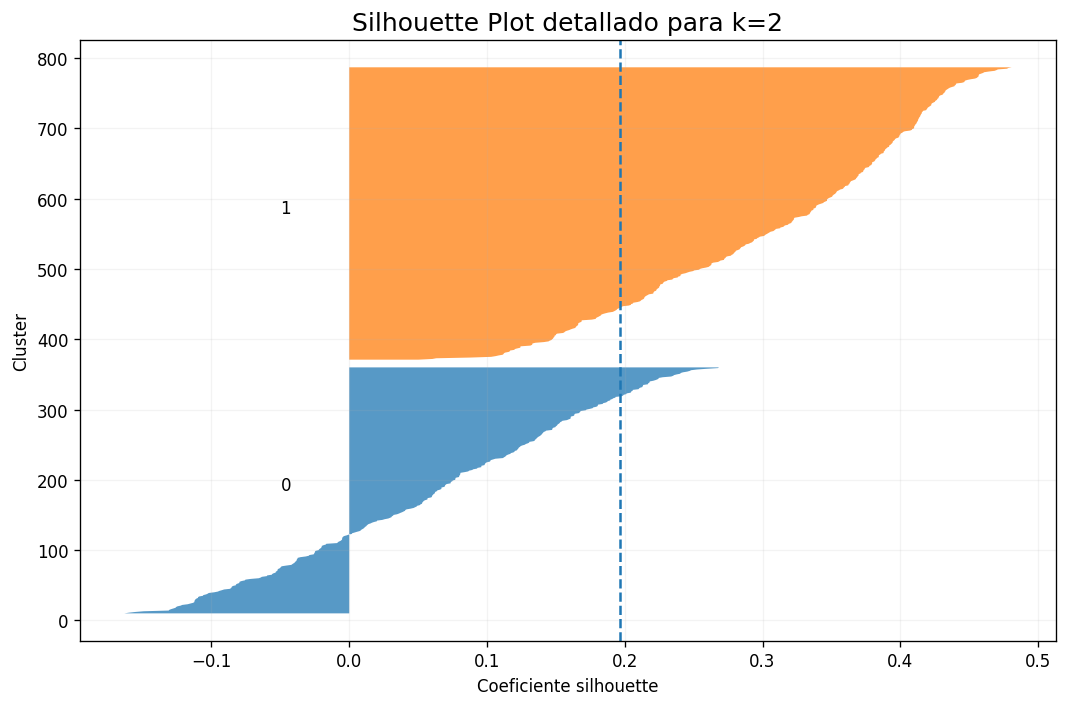

In [16]:
sil_values = silhouette_samples(X_scaled, clusters)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

for cluster_id in sorted(np.unique(clusters)):
    cluster_sil_values = sil_values[clusters == cluster_id]
    cluster_sil_values.sort()

    y_upper = y_lower + len(cluster_sil_values)

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_values, alpha=0.75)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sil_values), str(cluster_id))

    y_lower = y_upper + 10

ax.axvline(best_score, linestyle="--", linewidth=1.5)
ax.set_title(f"Silhouette Plot detallado para k={best_k}", fontsize=15)
ax.set_xlabel("Coeficiente silhouette")
ax.set_ylabel("Cluster")
ax.grid(alpha=0.15)
fig.tight_layout()
plt.show()

## 14. Clústeres k-Means visualizados en plano PCA

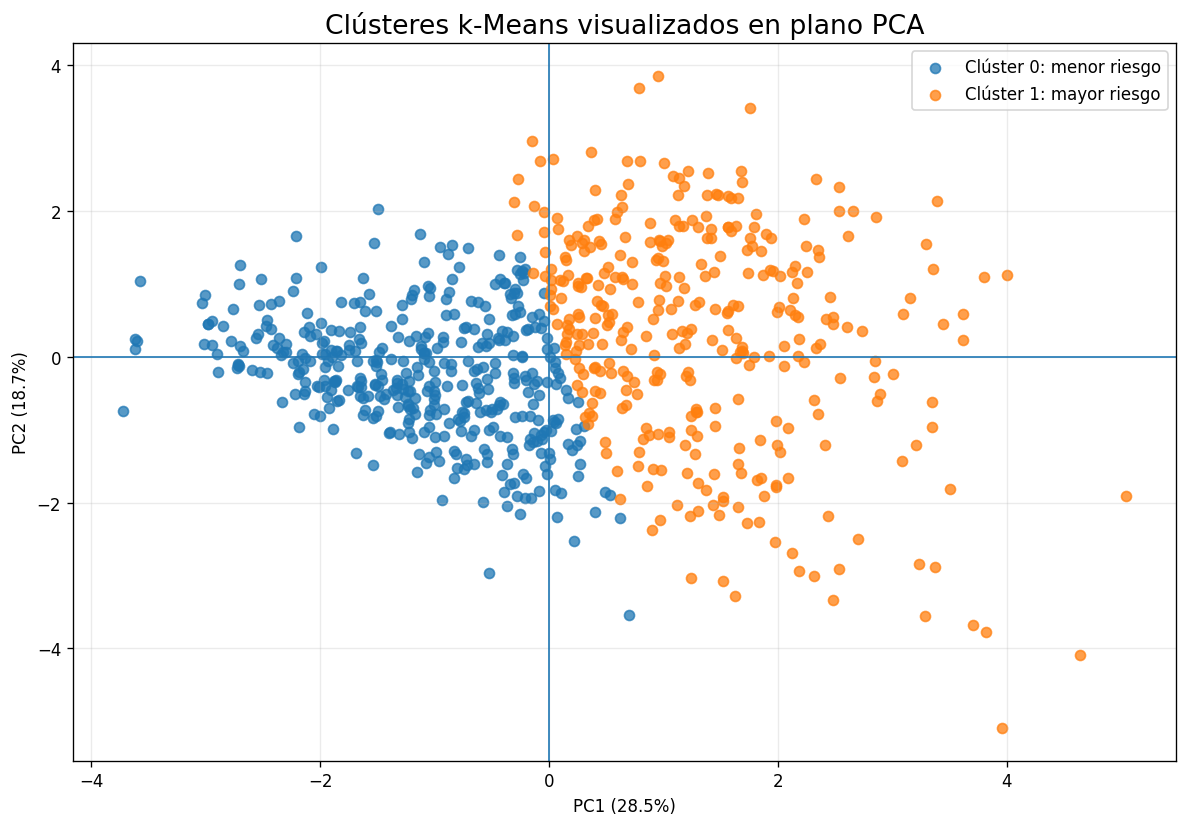

In [17]:
plt.figure(figsize=(10, 7))

for label in profile["Cluster Label"]:
    subset = df_result[df_result["Cluster Label"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.75, label=label)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Clústeres k-Means visualizados en plano PCA", fontsize=16)
plt.xlabel(f"PC1 ({pc1_var:.1f}%)")
plt.ylabel(f"PC2 ({pc2_var:.1f}%)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 15. Exportar tablas

In [18]:
output_dir = Path("outputs_fase_b")
output_dir.mkdir(exist_ok=True)

stats.round(2).to_csv(output_dir / "estadisticas_descriptivas.csv")
corr.round(3).to_csv(output_dir / "matriz_correlacion.csv")
pca_variance_table.round(2).to_csv(output_dir / "pca_varianza_explicada.csv", index=False)
silhouette_table.round(3).to_csv(output_dir / "silhouette_scores.csv", index=False)
profile_final.to_csv(output_dir / "perfil_clusters.csv", index=False)

print(f"Tablas exportadas en: {output_dir.resolve()}")

Tablas exportadas en: /content/outputs_fase_b


## 16. Texto sugerido para diapositivas

**EDA:** Después de imputar los valores clínicamente inválidos mediante mediana, se observaron distribuciones con asimetría en variables como `Insulin` y `Age`. El scatter plot `Glucose` vs `BMI` muestra que los pacientes con `Outcome = 1` tienden a concentrarse en zonas de mayor glucosa y mayor índice de masa corporal.

**Correlaciones:** El mapa de calor muestra que `Glucose` presenta la mayor correlación positiva con `Outcome`, seguida por `BMI`, `Age` y `Pregnancies`.

**PCA:** El scree plot sugiere conservar tres componentes principales bajo el criterio del codo. Para la visualización se usó el plano `PC1` vs `PC2`, ya que permite representar la estructura de los datos en dos dimensiones.

**k-Means:** El valor óptimo de `k` se seleccionó mediante el silhouette score promedio. Los clústeres resultantes se interpretaron según sus promedios clínicos y la proporción de `Outcome = 1`.